In [1]:
import tarfile
import torch    
import torch.nn as nn
import utils
from dataset.load_wsi_data import load_wsi_embeddings
import lightning.pytorch as pl
from torch.utils.data import DataLoader, random_split
from dataset.wsi_dataset import WSIDataset
from models.custom_transformer import VisionTransformer
from models.simple_transformer import SimpleTransformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
pl.seed_everything(seed)


Seed set to 42


42

In [ ]:
with tarfile.open('data/TCGA_BRCA', 'r') as archive:
    archive.extractall(path='./temp')

In [2]:
names, feats, coords, labels = load_wsi_embeddings('temp', 'data/sample_matrix.txt', device='cuda')

dataset = WSIDataset(feats, labels,coords, n_patches=32,seed=seed)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,generator = torch.Generator().manual_seed(seed))
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for batch_patches, batch_labels,batch_coords in train_loader:
    print(f"Batch patches shape: {batch_patches.shape}")
    print(f"Batch coords shape: {batch_patches.shape}")
    print(f"Batch labels shape: {batch_labels.shape}")
    break

Error loading TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF44-4C8946CDB47D.h5: single positional indexer is out-of-bounds
Error loading TCGA-A2-A0CY-01Z-00-DX1.8815F011-317B-4BB7-A48F-64EABD0E558B.h5: single positional indexer is out-of-bounds
Error loading TCGA-A8-A084-01Z-00-DX1.2B52D1B8-5AD4-4BD6-ADF7-9D65B8EE2621.h5: single positional indexer is out-of-bounds
Error loading TCGA-A8-A08F-01Z-00-DX1.9D2222F6-1425-46FD-BC94-728EF835FAC2.h5: single positional indexer is out-of-bounds
Error loading TCGA-A8-A08S-01Z-00-DX1.C0E044C2-FC3F-4E3D-A779-A725FF375F21.h5: single positional indexer is out-of-bounds
Error loading TCGA-A8-A09E-01Z-00-DX1.239A8E03-49EA-4C29-AF86-FC1BD8A9DB20.h5: single positional indexer is out-of-bounds
Error loading TCGA-A8-A09K-01Z-00-DX1.41B2DF5F-C0E1-43BB-BAA5-2946A9EC4650.h5: single positional indexer is out-of-bounds
Error loading TCGA-AO-A12C-01Z-00-DX1.F4105027-FA10-48AF-BA8F-C7A0181C4A1D.h5: single positional indexer is out-of-bounds
Error loading TCGA-AR-A2

In [ ]:
baseline_model = SimpleTransformer(embed_dim=1024, num_heads=4, num_layers=2, dropout=0.1).to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.0001)
classification_criterion = nn.BCEWithLogitsLoss()
utils.train(baseline_model,train_loader,optimizer,classification_criterion)

Epoch 1: Loss = 0.3968
Epoch 2: Loss = 0.3000
Epoch 3: Loss = 0.2083


In [5]:
model_with_distance = VisionTransformer(
    dim=1024,
    depth=2,
    heads=4,
    mlp_dim=1024,
    num_classes=1,
    dropout=0.1,
    distances_bin_width= 2048
).to(device)
optimizer = torch.optim.Adam(model_with_distance.parameters(), lr=0.0001)
classification_criterion = nn.BCEWithLogitsLoss()
losses = utils.train(model_with_distance,train_loader,optimizer,classification_criterion,ignore_coordinates=False)

Epoch 1: Loss = 0.3796
Epoch 2: Loss = 0.2554
Epoch 3: Loss = 0.1631
Epoch 4: Loss = 0.0634
Epoch 5: Loss = 0.0261
Epoch 6: Loss = 0.0081
Epoch 7: Loss = 0.0352
Epoch 8: Loss = 0.0364
Epoch 9: Loss = 0.0237
Epoch 10: Loss = 0.0111


In [4]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,roc_auc_score,recall_score
pl.seed_everything(seed)
test_predictions, test_labels, probas = utils.predict(baseline_model, test_loader, device)
# print("Predictions:", test_predictions)
# print("True Labels:", test_labels)
accuracy = accuracy_score(test_labels.numpy(), test_predictions.numpy())
auroc = roc_auc_score(test_labels.numpy(), probas.numpy())
f1 = f1_score(test_labels.numpy(), test_predictions.numpy())
precession = precision_score(test_labels.numpy(), test_predictions.numpy())
recall = recall_score(test_labels.numpy(), test_predictions.numpy())
print(f'Accuracy: {accuracy:.4f}')
print(f'AUROC: {auroc:.4f}')
print(f'F1: {f1:.4f}')
print(f'precession: {precession:.4f}')
print(f'recall: {recall:.4f}')


Seed set to 42


Accuracy: 0.8744
AUROC: 0.7831
F1: 0.3333
precession: 0.4667
recall: 0.2593


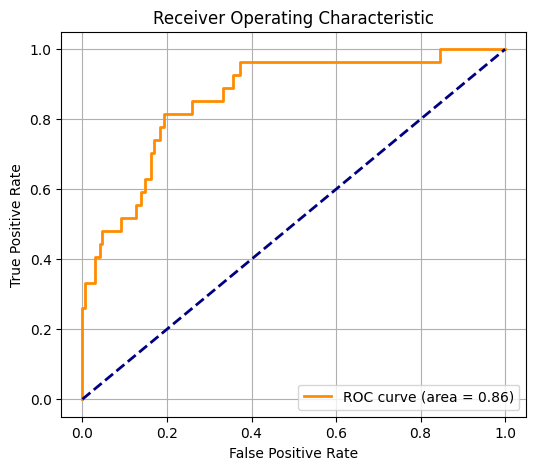

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels.numpy(),probas.numpy())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [6]:
pl.seed_everything(seed)

test_predictions, test_labels, probas = utils.predict(model_with_distance, test_loader, device,ignore_coordinates=False)
# print("Predictions:", test_predictions)
# print("True Labels:", test_labels)
accuracy = accuracy_score(test_labels.numpy(), test_predictions.numpy())
auroc = roc_auc_score(test_labels.numpy(), probas.numpy())
f1 = f1_score(test_labels.numpy(), test_predictions.numpy())
precession = precision_score(test_labels.numpy(), test_predictions.numpy())
recall = recall_score(test_labels.numpy(), test_predictions.numpy())
print(f'Accuracy: {accuracy:.4f}')
print(f'AUROC: {auroc:.4f}')
print(f'F1: {f1:.4f}')
print(f'precession: {precession:.4f}')
print(f'recall: {recall:.4f}')

Seed set to 42


Accuracy: 0.8789
AUROC: 0.8243
F1: 0.4000
precession: 0.5000
recall: 0.3333


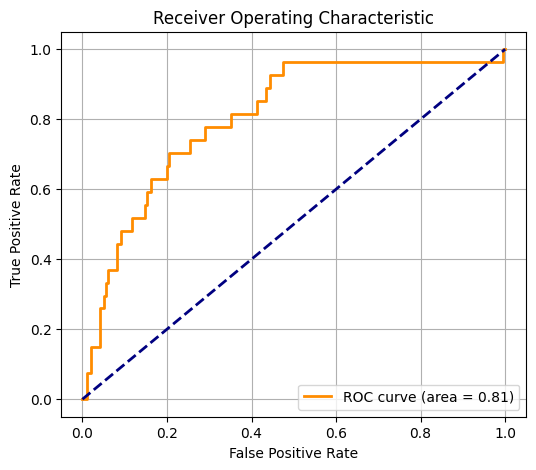

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels.numpy(),probas.numpy())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [1]:
from stamp.modeling.vision_transformer import VisionTransformer

def test_vision_transformer_dims(
    # arbitrarily chosen constants
    num_classes: int = 3,
    batch_size: int = 6,
    n_tiles: int = 75,
    input_dim: int = 456,
    n_heads: int = 4,
) -> None:
    model = VisionTransformer(
        dim_output=num_classes,
        dim_input=input_dim,
        dim_model=n_heads * 33,
        n_layers=3,
        n_heads=n_heads,
        dim_feedforward=135,
        dropout=0.12,
        use_alibi=False,
    )

    bags = torch.rand((batch_size, n_tiles, input_dim))
    coords = torch.rand((batch_size, n_tiles, 2))
    mask = torch.rand((batch_size, n_tiles)) > 0.5
    logits = model.forward(bags, coords=coords, mask=mask)
    assert logits.shape == (batch_size, num_classes)


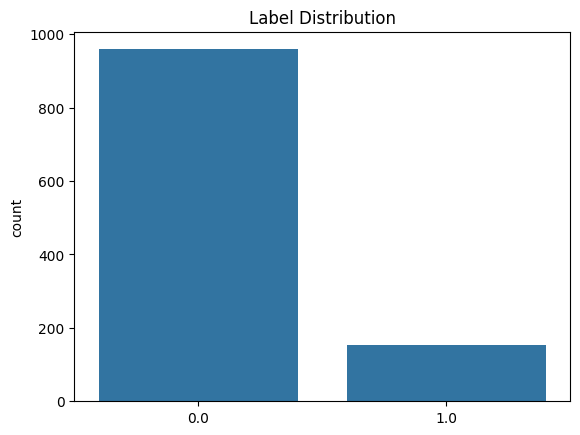

In [3]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt


# Convert tensors to a list of integers
label_list = [label.item() for label in labels]

# Now, you can use seaborn to plot the distribution
sns.countplot(x=label_list)
plt.title('Label Distribution')
plt.show()
